# Fashion MNIST Classification using CNN

## 🎯 Objective

Train a CNN to classify Fashion MNIST images.

---

## 📚 Dataset

60,000 Training Images

10,000 Testing Images

10 Clothing Classes

---

## 🧠 CNN Workflow

Load Dataset

↓

Normalize Images

↓

Build CNN

↓

Compile Model

↓

Train Model

↓

Evaluate

↓

Predict

---

## 📦 Import Libraries

---

## 💻 Implementation

---

## 📊 Results

Training Accuracy

Testing Accuracy

Predictions

---

## 📖 Conclusion

The CNN successfully classifies clothing images with high accuracy.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


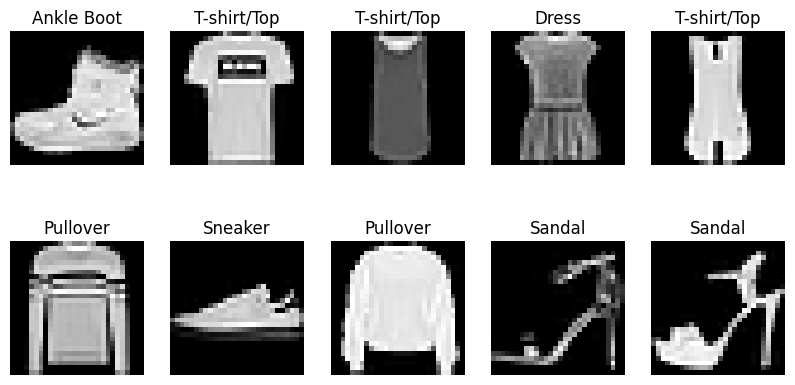

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.8287 - loss: 0.4735 - val_accuracy: 0.8645 - val_loss: 0.3706
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.8814 - loss: 0.3236 - val_accuracy: 0.8820 - val_loss: 0.3281
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.8968 - loss: 0.2771 - val_accuracy: 0.8961 - val_loss: 0.2878
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9099 - loss: 0.2455 - val_accuracy: 0.8967 - val_loss: 0.2799
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9192 - loss: 0.2194 - val_accuracy: 0.9040 - val_loss: 0.2635
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9040 - loss: 0.2635
Test Accuracy: 0.9039999842643738
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


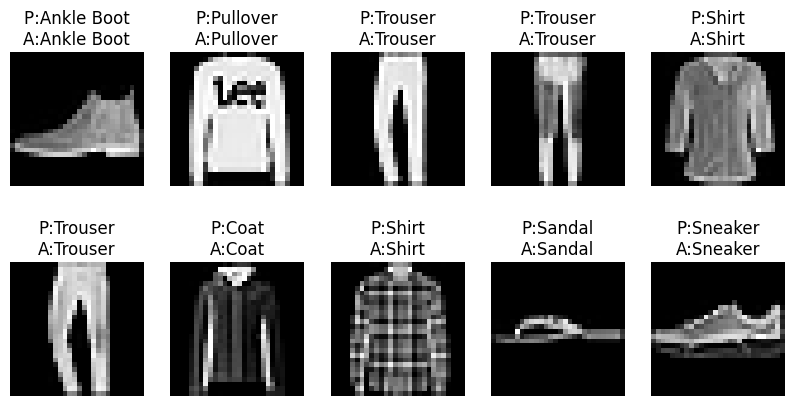

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

# Class names
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

# Display sample images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.show()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Evaluate
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

# Predict
predictions = model.predict(x_test)

# Display predictions
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    pred = np.argmax(predictions[i])
    plt.title(f"P:{class_names[pred]}\nA:{class_names[y_test[i]]}")
    plt.axis("off")

plt.show()